### **Imports**

In [50]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import plotly.express as px

### **Importing and Merging the Data Sets**

In [51]:
player_stats_all = pd.read_csv('players.csv')
player_stats_filter = pd.read_csv('player_stats.csv')
player_value = pd.read_csv('squads_and_players.csv')
merged_players_data = pd.merge(player_value, player_stats_filter, on=['player_id', 'team_id'], how='inner', suffixes=('_stats', '_value'))

# Select the required columns. Using the corrected market value column name.
player_market_value_df = merged_players_data[['player_id', 'team_id', 'player_name_stats', 'market_value_eur', 'position_stats']]

# Rename columns for clarity as requested by the user
player_market_value_df = player_market_value_df.rename(columns={'player_name_stats': 'player_name', 'market_value_eur': 'value', 'position_stats': 'position'})

display(player_market_value_df.head())

,player_id,team_id,player_name,value,position
0,1,1,José Raúl Rangel,8933646,GK
1,2,1,Jorge Eduardo Sanchez,24628639,DEF
2,3,1,César Jasib Montes,10912552,DEF
3,4,1,Edson Omar Alvarez,10875943,DEF
4,5,1,Johan Felipe Vasquez,18265363,DEF


In [52]:
#remove the middle name and accents in order to merge with the stats dataset
def remove_middle_name(full_name):
    parts = str(full_name).split()
    if len(parts) > 2:
        return parts[0] + ' ' + parts[-1]
    return full_name
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

player_market_value_df['player_name'] = player_market_value_df['player_name'].apply(remove_middle_name)
player_market_value_df['player_name'] = player_market_value_df['player_name'].apply(remove_accents)

display(player_market_value_df.head())

,player_id,team_id,player_name,value,position
0,1,1,Jose Rangel,8933646,GK
1,2,1,Jorge Sanchez,24628639,DEF
2,3,1,Cesar Montes,10912552,DEF
3,4,1,Edson Alvarez,10875943,DEF
4,5,1,Johan Vasquez,18265363,DEF


In [53]:
# Apply the same cleaning functions to player_stats_all['player']
player_stats_all['player'] = player_stats_all['player'].apply(remove_middle_name)
player_stats_all['player'] = player_stats_all['player'].apply(remove_accents)

# Rename the 'player' column in player_stats_all to 'player_name' for merging
player_stats_all = player_stats_all.rename(columns={'player': 'player_name'})

#Drop player position in this dataframe since the other dataframe has a more accurate position column
player_stats_all = player_stats_all.drop(columns=['position'])

In [54]:
player_df = pd.merge(
    player_market_value_df,
    player_stats_all,
    on='player_name',
    how='left'
)
player_df = player_df.drop(columns = ['player_id', 'team_id'])
model_results = pd.DataFrame(columns = ['Model','Position', 'MAE', 'RMSE','R2'])
player_df

,player_name,value,position,team,team_country,age,birth_year,club,games,games_starts,...,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Jose Rangel,8933646,GK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Jorge Sanchez,24628639,DEF,Mexico,Mexico,28.0,1997.0,PAOK,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cesar Montes,10912552,DEF,Mexico,Mexico,29.0,1997.0,Loko Moscow,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Edson Alvarez,10875943,DEF,Mexico,Mexico,28.0,1997.0,West Ham,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Johan Vasquez,18265363,DEF,Mexico,Mexico,27.0,1998.0,Genoa,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1244,Orlando Mosquera,700000,GK,Panama,Panama,31.0,1994.0,Al-Fayha,3.0,3.0,...,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1245,Michael Murillo,7830169,DEF,Panama,Panama,30.0,1996.0,Beşiktaş,3.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1246,Azarias Londono,4490434,FWD,Panama,Panama,24.0,2001.0,Univ Católica,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1247,Roderick Miller,9948860,DEF,Panama,Panama,34.0,1992.0,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Cleaning**

In [55]:
goalkeepers_df = player_df[player_df['position'] == 'GK']
goalkeeper_features = [
    # Player context
    'player_name',
    'team',
    'age',

    # Goalkeeper playing time
    'gk_minutes',

    # Shot stopping
    'gk_goals_against_per90',
    'gk_shots_on_target_against',
    'gk_saves',
    'gk_save_pct',

    # Results and clean sheets
    'gk_clean_sheets',

    # Penalty performance
    'gk_pens_allowed',
    'gk_pens_saved',

    # Target value
    'value'
]
goalkeepers_df = goalkeepers_df[goalkeeper_features]


#drop goalkeepers with no games played
goalkeepers_df = goalkeepers_df.dropna(subset=['gk_minutes'])

#fill gk_save_pct with median for the gks with null
goalkeepers_df['gk_save_pct'] = goalkeepers_df['gk_save_pct'].fillna(goalkeepers_df['gk_save_pct'].median())

In [56]:
#Linear Regression baseline for goalkeepers
gk_X = goalkeepers_df.drop(columns=['player_name', 'value'])
gk_y = goalkeepers_df['value']
X_train, X_test, y_train, y_test = train_test_split(gk_X, gk_y, test_size=0.2, random_state=42)

#GK numerical and categorical features
gk_categorical_features = gk_X.select_dtypes(include=['object']).columns
gk_numerical_features = gk_X.select_dtypes(include=['int64', 'float64']).columns

#Numerical pipeline
gk_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical pipeline
gk_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
gk_preprocessor = ColumnTransformer(
    transformers=[
        ('num', gk_numerical_pipe, gk_numerical_features),
        ('cat', gk_categorical_pipe, gk_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
gk_pipe = Pipeline([
    ('preprocessor', gk_preprocessor),
    ('regressor', LinearRegression())
])

gk_pipe.fit(X_train, y_train)
gk_pred = gk_pipe.predict(X_test)
gk_mae = mean_absolute_error(y_test, gk_pred)
gk_rmse = root_mean_squared_error(y_test, gk_pred)
gk_r2 = gk_pipe.score(X_test, y_test)

#Append to results df
model_results.loc[len(model_results)] = ['Multi Linear Regression', 'Goalkeeper', gk_mae,gk_rmse, gk_r2]

In [57]:
defenders_df = player_df[player_df['position'] == 'DEF']
defender_features = [
    # Player context
    'player_name',
    'age',
    'team',
    'minutes_90s',

    # Defensive performance
    'interceptions',
    'tackles_won',
    'fouls',
    'cards_yellow',
    'cards_red',

    # Team performance
    'plus_minus_per90',

    # Offensive contribution
    'goals',
    'assists',
    'crosses',

    #Target value
    'value'
]
#parse for only defender features
defenders_df = defenders_df[defender_features]

#drop any values that are null
defenders_df = defenders_df.dropna(subset = ['minutes_90s'])

In [58]:
forwards_df = player_df[player_df['position'] == 'FWD']
forward_features = [
    # Player context
    'player_name',
    'age',
    'team',
    'minutes_90s',

    # Scoring
    'goals_pens_per90',

    # Chance creation
    'assists_per90',

    # Shooting
    'shots_per90',
    'shots_on_target_per90',

    # Attacking activity
    'offsides',
    'fouled',
    'crosses',

    # Team performance
    'plus_minus_per90',

    # Target value
    'value'
]
#parse for only forward_features
forwards_df = forwards_df[forward_features]

#parse out any nulls
forwards_df = forwards_df.dropna(subset = ['minutes_90s'])

In [59]:
midfielders_df = player_df[player_df['position'] == 'MID']
midfielder_features = [
    # Player context
    'player_name',
    'age',
    'team',
    'minutes_90s',

    # Attacking contribution
    'goals_per90',
    'assists_per90',
    'shots_per90',
    'shots_on_target_per90',
    'crosses',

    # Defensive and possession-related contribution
    'interceptions',
    'tackles_won',
    'fouls',
    'fouled',

    # Team performance
    'plus_minus_per90',

    # Target value
    'value'
]
#parse for only midfielder_features
midfielders_df = midfielders_df[midfielder_features]
#parse out null values
midfielders_df = midfielders_df.dropna(subset = ['minutes_90s'])

### **Outlier Check**

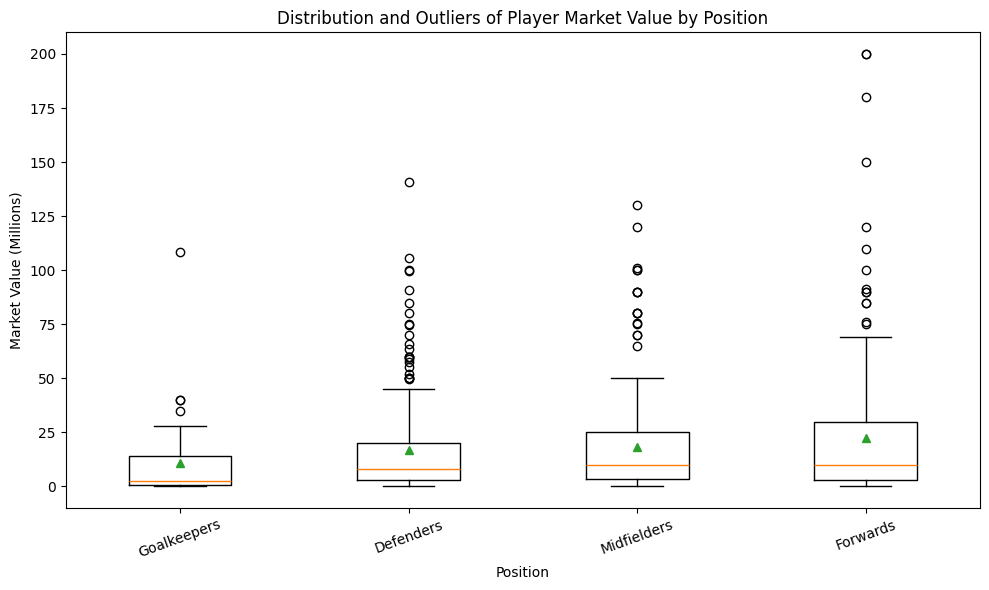

In [60]:
# @title
#positional values in millions
position_data = [
    goalkeepers_df['value'].dropna() / 1_000_000,
    defenders_df['value'].dropna() / 1_000_000,
    midfielders_df['value'].dropna() / 1_000_000,
    forwards_df['value'].dropna() / 1_000_000
]

plt.figure(figsize=(10, 6))

#boxplots for each position
plt.boxplot(
    position_data,
    tick_labels=[
        'Goalkeepers',
        'Defenders',
        'Midfielders',
        'Forwards'
    ],
    showmeans=True
)

plt.title('Distribution and Outliers of Player Market Value by Position')
plt.xlabel('Position')
plt.ylabel('Market Value (Millions)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [61]:
#Function that removes outliers for a given dataframe and column value
def remove_outliers_iqr(df, column='value'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ].copy()

    return cleaned_df

#Applying this onto the positional dataframes
goalkeepers_df = remove_outliers_iqr(goalkeepers_df)
defenders_df = remove_outliers_iqr(defenders_df)
midfielders_df = remove_outliers_iqr(midfielders_df)
forwards_df = remove_outliers_iqr(forwards_df)

### **Baseline Model Creation**

In [62]:
#Linear Regression baseline for defenders
defender_X = defenders_df.drop(columns=['player_name', 'value'])
defender_y = defenders_df['value']
defender_X_train, defender_X_test, defender_y_train, defender_y_test = train_test_split(defender_X, defender_y, test_size=0.2, random_state=42)

#Defender numerical and categorical features
defender_categorical_features = defender_X.select_dtypes(include=['object']).columns
defender_numerical_features = defender_X.select_dtypes(include=['int64', 'float64']).columns

#Numerical pipeline
defender_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical pipeline
defender_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
defender_preprocessor = ColumnTransformer(
    transformers=[
        ('num', defender_numerical_pipe, defender_numerical_features),
        ('cat', defender_categorical_pipe, defender_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
defender_pipe = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('regressor', LinearRegression())
])
defender_pipe.fit(defender_X_train, defender_y_train)
defender_pred = defender_pipe.predict(defender_X_test)
defender_mae = mean_absolute_error(defender_y_test, defender_pred)
defender_r2 = defender_pipe.score(defender_X_test, defender_y_test)
defender_rmse = root_mean_squared_error(defender_y_test, defender_pred)

#Append to results df
model_results.loc[len(model_results)] = ['Multi Linear Regression','Defender', defender_mae, defender_rmse, defender_r2]

In [63]:
#Train/test split for midfielders data
midfielder_X = midfielders_df.drop(columns=['player_name', 'value'])
midfielder_y = midfielders_df['value']
midfielder_X_train, midfielder_X_test, midfielder_y_train, midfielder_y_test = train_test_split(midfielder_X, midfielder_y, test_size=0.2, random_state=42)

#Midfielder numerical and categorical features
midfielder_numerical_features = midfielder_X.select_dtypes(include=['int64', 'float64']).columns
midfielder_categorical_features = midfielder_X.select_dtypes(include=['object']).columns

#Numerical Pipeline
midfielder_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical Pipeline
midfielder_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
midfielder_preprocessor = ColumnTransformer(
    transformers=[
        ('num', midfielder_numerical_pipe, midfielder_numerical_features),
        ('cat', midfielder_categorical_pipe, midfielder_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
midfielder_pipe = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('regressor', LinearRegression())
])
midfielder_pipe.fit(midfielder_X_train, midfielder_y_train)
midfielder_pred = midfielder_pipe.predict(midfielder_X_test)
midfielder_mae = mean_absolute_error(midfielder_y_test, midfielder_pred)
midfielder_r2 = midfielder_pipe.score(midfielder_X_test, midfielder_y_test)
midfielder_rmse = root_mean_squared_error(midfielder_y_test, midfielder_pred)

#Append to results df
model_results.loc[len(model_results)] = ['Multi Linear Regression', 'Midfielder', midfielder_mae, midfielder_rmse, midfielder_r2]

In [64]:
#Train/test split for forwards data
forward_X = forwards_df.drop(columns=['player_name', 'value'])
forward_y = forwards_df['value']
forward_X_train, forward_X_test, forward_y_train, forward_y_test = train_test_split(forward_X, forward_y, test_size=0.2, random_state=42)

#Forward numerical and categorical features
forward_categorical_features = forward_X.select_dtypes(include=['object']).columns
forward_numerical_features = forward_X.select_dtypes(include=['int64', 'float64']).columns

#Numerical pipeline
forward_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical pipeline
forward_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
forward_preprocessor = ColumnTransformer(
    transformers=[
        ('num', forward_numerical_pipe, forward_numerical_features),
        ('cat', forward_categorical_pipe, forward_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
forward_pipe = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('regressor', LinearRegression())
])

forward_pipe.fit(forward_X_train, forward_y_train)
forward_pred = forward_pipe.predict(forward_X_test)

forward_pipe.fit(forward_X_train, forward_y_train)
forward_pred = forward_pipe.predict(forward_X_test)
forward_mae = mean_absolute_error(forward_y_test, forward_pred)
forward_r2 = forward_pipe.score(forward_X_test, forward_y_test)
forward_rmse = root_mean_squared_error(forward_y_test, forward_pred)

#Append to results df
model_results.loc[len(model_results)] = ['Multi Linear Regression', 'Forward', forward_mae, forward_rmse, forward_r2]

### **Baseline Analysis**

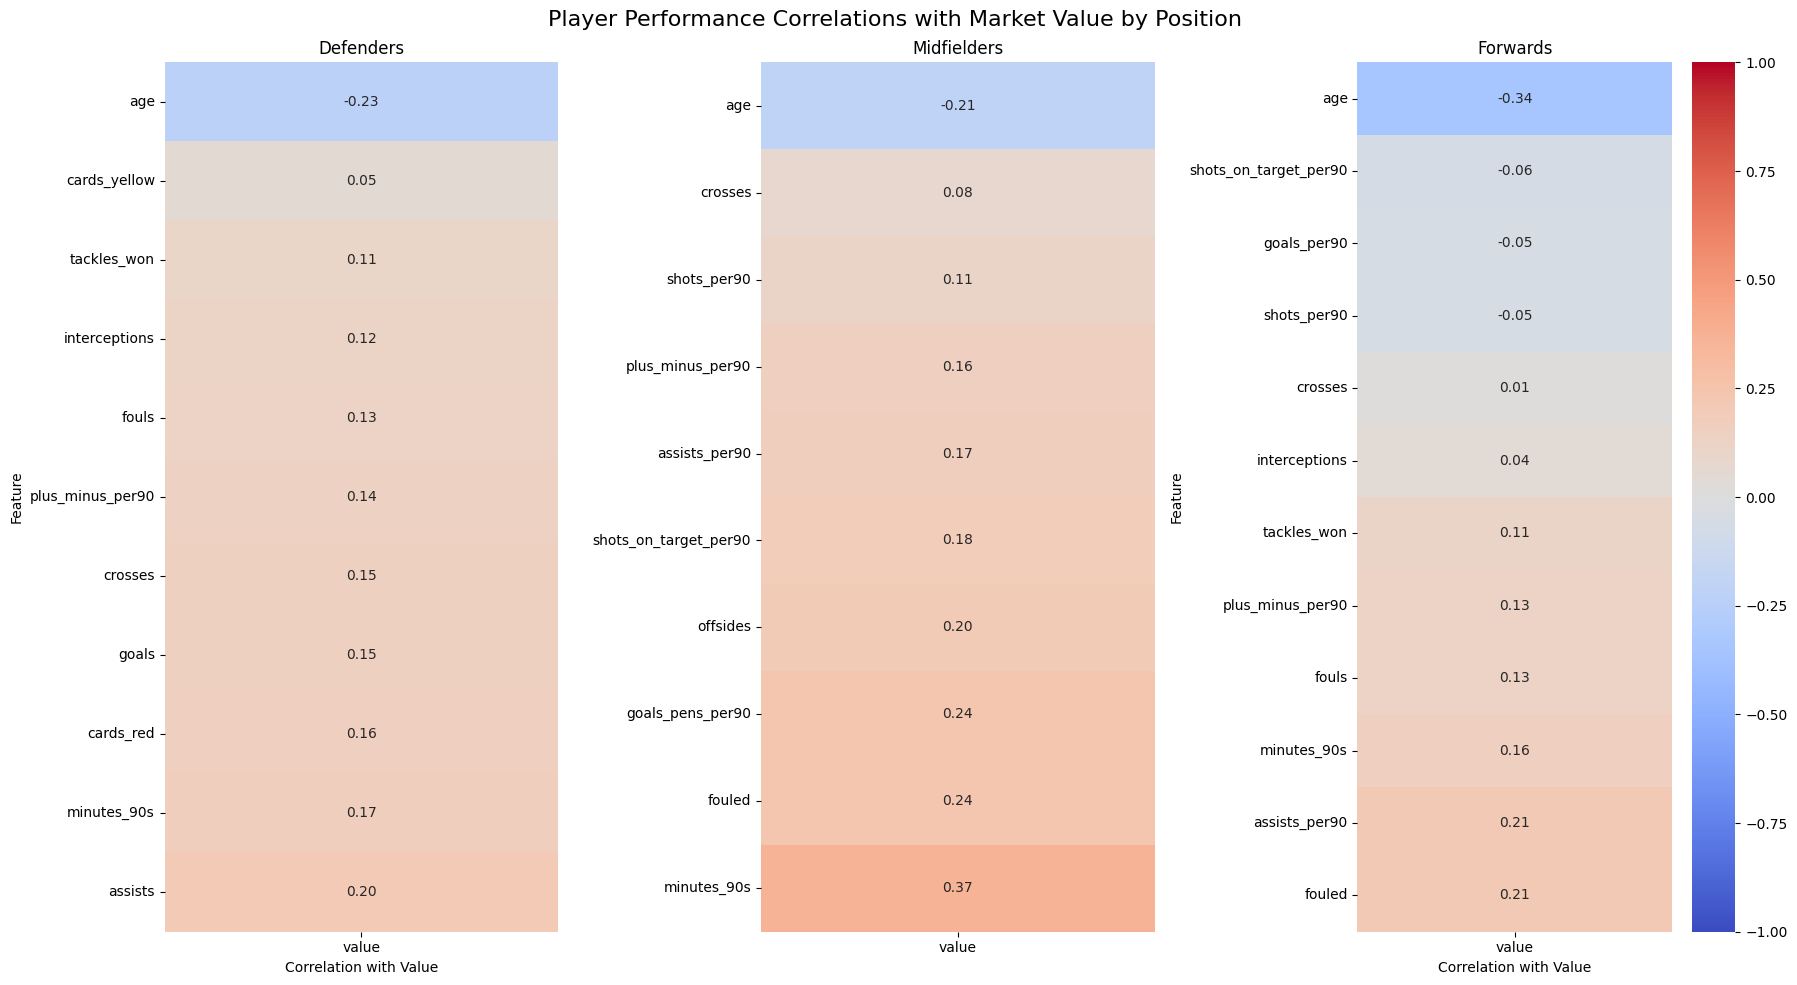

In [65]:
# @title
#Plotting heatmaps for the different positions
defender_corr = defenders_df.corr(numeric_only=True)['value'].drop('value').sort_values()
forward_corr = forwards_df.corr(numeric_only=True)['value'].drop('value').sort_values()
midfielder_corr = midfielders_df.corr(numeric_only=True)['value'].drop('value').sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

#defender heatmap
sns.heatmap(
    defender_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[0],
    cbar=False
)
axes[0].set_title('Defenders')
axes[0].set_xlabel('Correlation with Value')
axes[0].set_ylabel('Feature')



#midfielder heatmap
sns.heatmap(
    midfielder_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[2]
)
axes[1].set_title('Midfielders')
axes[1].set_xlabel('Correlation with Value')
axes[1].set_ylabel('Feature')

#forward heatmap
sns.heatmap(
    forward_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[1],
    cbar=False
)
axes[2].set_title('Forwards')
axes[2].set_xlabel('Correlation with Value')
axes[2].set_ylabel('Feature')

fig.suptitle(
    'Player Performance Correlations with Market Value by Position',
    fontsize=16
)

plt.tight_layout()
plt.show()

The heatmaps above show how individual Worldcup performance stats correlate with player market value.

One important thing to note is that all three graphs have age as the most negatively correlated stat, suggesting that younger players tend to earn more money than older players. This makes sense because younger players have better fitness and are closer to their prime.

Furthemore, minutes played per 90 seconds are amongst the higher correlated features, suggesting that players who have more field time earn more. This sounds reasonable because players with high playing time tend to have stronger technical abilities, knowledge, and trust from management, all strong factors for higher market values.

Surprisingly, position based statistics alone don't have a high correlation with market value. This suggests that market values heavily rely on a plethora of stats. As a result, I have chosen to use **Multiple Linear Regression** as a baseline model because it can evaluate a multitude of player attributes while remaining interpretable.



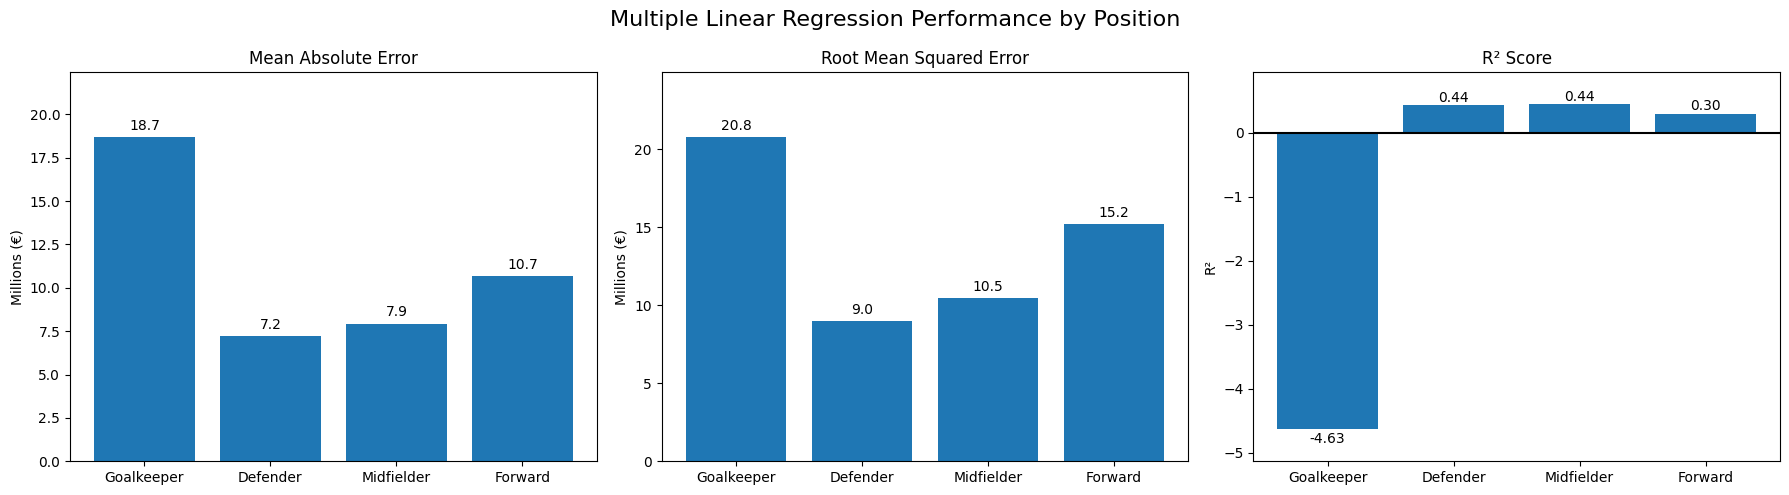

In [66]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convert to millions
mae = model_results['MAE'] / 1_000_000
rmse = model_results['RMSE'] / 1_000_000
r2 = model_results['R2']


# MAE

bars = axes[0].bar(model_results['Position'], mae)

axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('Millions (€)')
axes[0].set_ylim(0, mae.max()*1.2)

axes[0].bar_label(
    bars,
    labels=[f'{x:.1f}' for x in mae],
    padding=3
)


# RMSE

bars = axes[1].bar(model_results['Position'], rmse)

axes[1].set_title('Root Mean Squared Error')
axes[1].set_ylabel('Millions (€)')
axes[1].set_ylim(0, rmse.max()*1.2)

axes[1].bar_label(
    bars,
    labels=[f'{x:.1f}' for x in rmse],
    padding=3
)

# R2 Score

bars = axes[2].bar(model_results['Position'], r2)

axes[2].axhline(0, color='black')
axes[2].set_title('R² Score')
axes[2].set_ylabel('R²')

axes[2].set_ylim(
    r2.min()-0.5,
    r2.max()+0.5
)

for bar, value in zip(bars, r2):
    if value >= 0:
        axes[2].text(
            bar.get_x()+bar.get_width()/2,
            value+0.05,
            f'{value:.2f}',
            ha='center'
        )
    else:
        axes[2].text(
            bar.get_x()+bar.get_width()/2,
            value-0.05,
            f'{value:.2f}',
            ha='center',
            va='top'
        )

fig.suptitle(
    'Multiple Linear Regression Performance by Position',
    fontsize=16
)

plt.tight_layout()
plt.show()

The table above reveals the mean absolute error and r2 score for the  multiple linear regression models created for each position. Mean absolute error was picked as the primary model performance metric because it measures the average error in euros between the predicted and true market values, making it easy to understand. RMSE was used as a secondary metric to penalize **outliers** and tests whether MAE was a good primary metric.

The most important result to note is that the goalkeeper data got an R2 score of -4.63. This makes sense because after cleaning the data, only 39 goalies were chosen for modeling. Such a small sample size will produce useless models. As a result, future models will not include goalkeeper data.

The remaining models have a relatively medium R2 value. This makes sense because the dataset reflects player stats during a month long tournament and doesn't include key features that play a role in player cost. Lack of stats and time makes Linear Regression have a performance cap. Further modeling may be able to improve these metrics.

Another interesting observation is that the MAE and RMSE graphs for defenders, midfielders, and forwards look the same, except the RMSE values are slightly larger. The difference in magnitude makes sense because RMSE squares before averaging, making the final results larger. The more important thing is that the relative performance across position stayed about the same. This suggests that Linear Regression was able to handle outliers in the dataset or that there aren't enough outliers to skew the data.



### **Stronger Model Analsysis**

The three models chosen to analyze the data set are Ridge Regression, Random Forest Regression, and Gradient Boosting Regression.

Since most stats per position are corellated, Ridge was chosen to make sure one stat would not influence the overall models decision.

Random Forest was chosen to check if there were more complex relationships between player features that predicted player price better than multi linear regression.

Gradient Boosting was chosen to see if improving a models error sequentially would yield better prediction values.

In [67]:
#Function to evaulate the models mae, rmse, and r2 score
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

In [68]:
# Ridge Analsyis for each position

#Defenders
defender_ridge = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('ridge', Ridge(alpha=1.0))
])
defender_ridge.fit(defender_X_train, defender_y_train)
defender_ridge_mae, defender_ridge_rmse, defender_ridge_r2 = evaluate_model(defender_ridge, defender_X_test, defender_y_test)
model_results.loc[len(model_results)] = ['Ridge Regression', 'Defender', defender_ridge_mae, defender_ridge_rmse, defender_ridge_r2]

#Midfielders
midfielder_ridge = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('ridge', Ridge(alpha = 1.0))
])
midfielder_ridge.fit(midfielder_X_train, midfielder_y_train)
midfielder_ridge_mae, midfielder_ridge_rmse, midfielder_ridge_r2 = evaluate_model(midfielder_ridge, midfielder_X_test, midfielder_y_test)
model_results.loc[len(model_results)] = ['Ridge Regression', 'Midfielder', midfielder_ridge_mae, midfielder_ridge_rmse, midfielder_ridge_r2]

#Forwards

forward_ridge = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('ridge', Ridge(alpha = 1.0))
])
forward_ridge.fit(forward_X_train, forward_y_train)
forward_ridge_mae, forward_ridge_rmse, forward_ridge_r2 = evaluate_model(forward_ridge, forward_X_test, forward_y_test)
model_results.loc[len(model_results)] = ['Ridge Regression', 'Forward', forward_ridge_mae, forward_ridge_rmse, forward_ridge_r2]


In [69]:
# Random Forest analysis for each position

#Defenders
defender_RF = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('RF', RandomForestRegressor(n_estimators=100, random_state=42))
])
defender_RF.fit(defender_X_train, defender_y_train)
defender_RF_mae, defender_RF_rmse, defender_RF_r2 = evaluate_model(defender_RF, defender_X_test, defender_y_test)
model_results.loc[len(model_results)] = ['Random Forest', 'Defender', defender_RF_mae, defender_RF_rmse, defender_RF_r2]

#Midfielders
midfielder_RF = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('RF', RandomForestRegressor(n_estimators=100, random_state=42))
])
midfielder_RF.fit(midfielder_X_train, midfielder_y_train)
midfielder_RF_mae, midfielder_RF_rmse, midfielder_RF_r2 = evaluate_model(midfielder_RF, midfielder_X_test, midfielder_y_test)
model_results.loc[len(model_results)] = ['Random Forest', 'Midfielder', midfielder_RF_mae, midfielder_RF_rmse, midfielder_RF_r2]

#Forwards

forward_RF = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('RF', RandomForestRegressor(n_estimators=100, random_state=42))
])
forward_RF.fit(forward_X_train, forward_y_train)
forward_RF_mae, forward_RF_rmse, forward_RF_r2 = evaluate_model(forward_RF, forward_X_test, forward_y_test)
model_results.loc[len(model_results)] = ['Random Forest', 'Forward', forward_RF_mae, forward_RF_rmse, forward_RF_r2]


In [70]:
# Gradient Boosting Regressor analysis for each position

#Defenders
defender_gb = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
defender_gb.fit(defender_X_train, defender_y_train)
defender_gb_mae, defender_gb_rmse, defender_gb_r2 = evaluate_model(defender_gb, defender_X_test, defender_y_test)
model_results.loc[len(model_results)] = ['Gradient Boosting', 'Defender', defender_gb_mae, defender_gb_rmse, defender_gb_r2]

#Midfielders
midfielder_gb = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
midfielder_gb.fit(midfielder_X_train, midfielder_y_train)
midfielder_gb_mae, midfielder_gb_rmse, midfielder_gb_r2 = evaluate_model(midfielder_gb, midfielder_X_test, midfielder_y_test)
model_results.loc[len(model_results)] = ['Gradient Boosting', 'Midfielder', midfielder_gb_mae, midfielder_gb_rmse, midfielder_gb_r2]

#Forwards
forward_gb = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
forward_gb.fit(forward_X_train, forward_y_train)
forward_gb_mae, forward_gb_rmse, forward_gb_r2 = evaluate_model(forward_gb, forward_X_test, forward_y_test)
model_results.loc[len(model_results)] = ['Gradient Boosting', 'Forward', forward_gb_mae, forward_gb_rmse, forward_gb_r2]

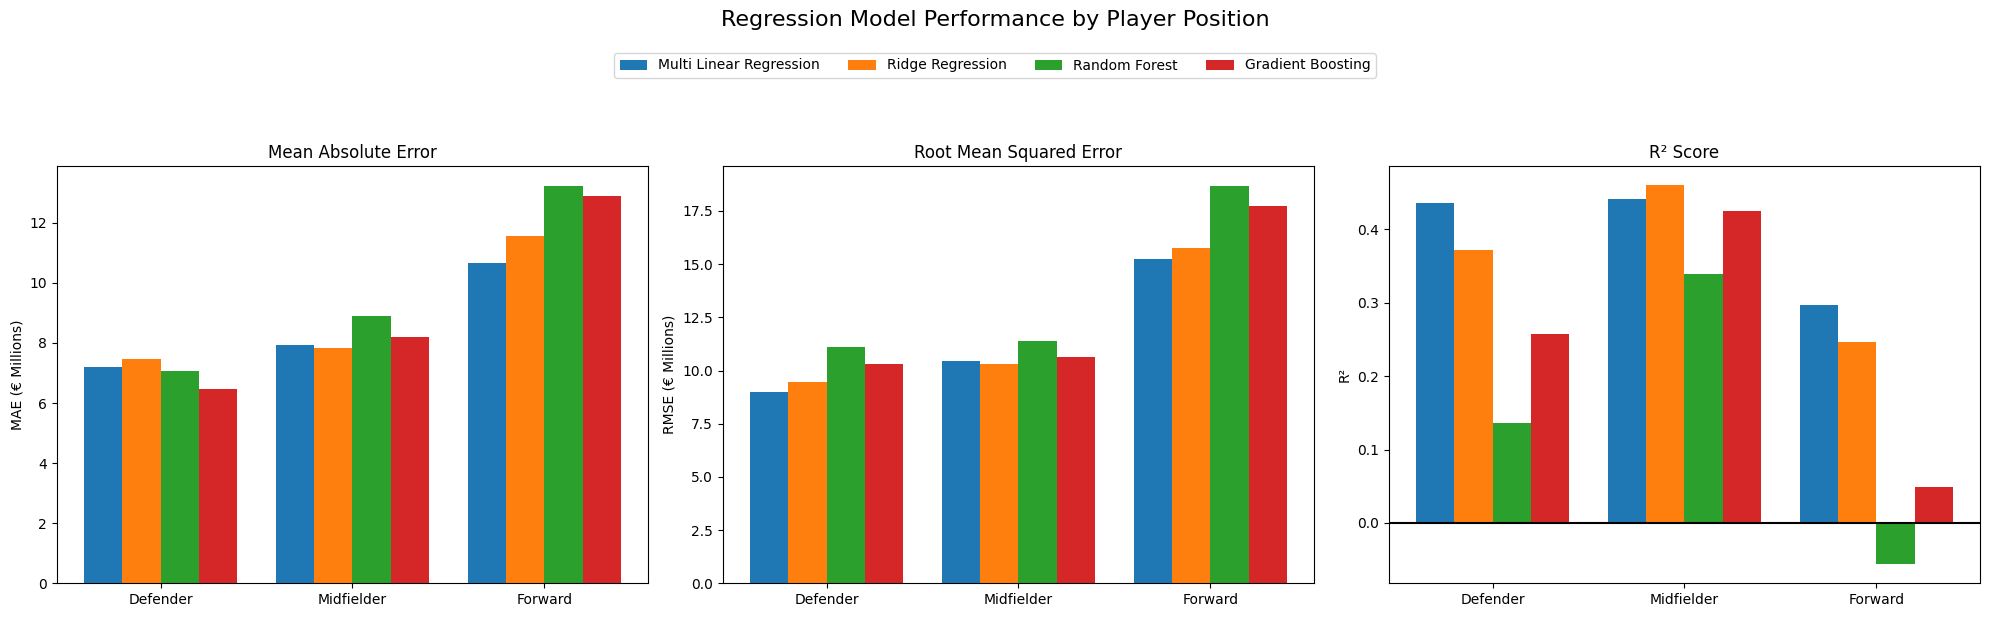

In [71]:
# @title
# Convert MAE and RMSE to millions
plot_results = model_results.copy()

plot_results['MAE_Millions'] = (
    plot_results['MAE'] / 1_000_000
)

plot_results['RMSE_Millions'] = (
    plot_results['RMSE'] / 1_000_000
)

positions = ['Defender', 'Midfielder', 'Forward']

models = [
    'Multi Linear Regression',
    'Ridge Regression',
    'Random Forest',
    'Gradient Boosting'
]

x = np.arange(len(positions))
width = 0.2

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, model in enumerate(models):

    data = plot_results[
        plot_results['Model'] == model
    ].set_index('Position').reindex(positions)

    axes[0].bar(
        x + i * width,
        data['MAE_Millions'],
        width,
        label=model
    )

axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('MAE (€ Millions)')
axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(positions)

for i, model in enumerate(models):

    data = plot_results[
        plot_results['Model'] == model
    ].set_index('Position').reindex(positions)

    axes[1].bar(
        x + i * width,
        data['RMSE_Millions'],
        width,
        label=model
    )

axes[1].set_title('Root Mean Squared Error')
axes[1].set_ylabel('RMSE (€ Millions)')
axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels(positions)

for i, model in enumerate(models):

    data = plot_results[
        plot_results['Model'] == model
    ].set_index('Position').reindex(positions)

    axes[2].bar(
        x + i * width,
        data['R2'],
        width,
        label=model
    )

axes[2].axhline(0, color='black')

axes[2].set_title('R² Score')
axes[2].set_ylabel('R²')
axes[2].set_xticks(x + 1.5 * width)
axes[2].set_xticklabels(positions)


# One legend for entire figure
handles, labels = axes[0].get_legend_handles_labels()

fig.suptitle(
    'Regression Model Performance by Player Position',
    fontsize=16,
    y=1.02
)

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.96)
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.show()

### **Tuning the Model via GridSearchCV**

In [72]:
#Grid Search CV paramater grid
ridge_params = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}
rf_params = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10, None],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 1.0]
}

gb_params = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.05, 0.1],
    'gb__max_depth': [2, 3, 5],
    'gb__min_samples_split': [2, 5],
    'gb__min_samples_leaf': [1, 2]
}

In [73]:
#Defender Ridge Grid Search
defender_ridge_tune = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('ridge', Ridge())
])

defender_ridge_grid = GridSearchCV(estimator = defender_ridge_tune, param_grid = ridge_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
defender_ridge_grid.fit(defender_X_train, defender_y_train)
defender_ridge_mae_tuned, defender_ridge_rmse_tuned, defender_ridge_r2_tuned = evaluate_model(defender_ridge_grid, defender_X_test, defender_y_test)
model_results.loc[len(model_results)] = ['Ridge Tuned', 'Defender', defender_ridge_mae_tuned, defender_ridge_rmse_tuned, defender_ridge_r2_tuned]

In [74]:
#Midfielder Ridge Grid Search
midfielder_ridge_tune = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('ridge', Ridge())
])

midfielder_ridge_grid = GridSearchCV(estimator = midfielder_ridge_tune, param_grid = ridge_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
midfielder_ridge_grid.fit(midfielder_X_train, midfielder_y_train)
midfielder_ridge_mae_tuned, midfielder_ridge_rmse_tuned, midfielder_ridge_r2_tuned = evaluate_model(midfielder_ridge_grid, midfielder_X_test, midfielder_y_test)
model_results.loc[len(model_results)] = ['Ridge Tuned', 'Midfielder', midfielder_ridge_mae_tuned, midfielder_ridge_rmse_tuned, midfielder_ridge_r2_tuned]

In [75]:
#Forward Ridge Grid Search
forward_ridge_tune = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('ridge', Ridge())
])

forward_ridge_grid = GridSearchCV(estimator = forward_ridge_tune, param_grid = ridge_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
forward_ridge_grid.fit(forward_X_train, forward_y_train)
forward_ridge_mae_tuned, forward_ridge_rmse_tuned, forward_ridge_r2_tuned = evaluate_model(forward_ridge_grid, forward_X_test, forward_y_test)
model_results.loc[len(model_results)] = ['Ridge Tuned', 'Forward', forward_ridge_mae_tuned, forward_ridge_rmse_tuned, forward_ridge_r2_tuned]

In [76]:
defender_RF_tuned = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

defender_RF_grid = GridSearchCV(estimator = defender_RF_tuned, param_grid = rf_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
defender_RF_grid.fit(defender_X_train, defender_y_train)
defender_RF_mae_tuned, defender_RF_rmse_tuned, defender_RF_r2_tuned = evaluate_model(defender_RF_grid, defender_X_test, defender_y_test)
model_results.loc[len(model_results)] = ['Random Forest Tuned', 'Defender', defender_RF_mae_tuned, defender_RF_rmse_tuned, defender_RF_r2_tuned]


In [77]:
midfielder_RF_tuned = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

midfielder_RF_grid = GridSearchCV(estimator = midfielder_RF_tuned, param_grid = rf_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
midfielder_RF_grid.fit(midfielder_X_train, midfielder_y_train)
midfielder_RF_mae_tuned, midfielder_RF_rmse_tuned, midfielder_RF_r2_tuned = evaluate_model(midfielder_RF_grid, midfielder_X_test, midfielder_y_test)
model_results.loc[len(model_results)] = ['Random Forest Tuned', 'Midfielder', midfielder_RF_mae_tuned, midfielder_RF_rmse_tuned, midfielder_RF_r2_tuned]


In [78]:
#Forward Random Forest GridSearch
forward_RF_tuned = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

forward_RF_grid = GridSearchCV(estimator = forward_RF_tuned, param_grid = rf_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
forward_RF_grid.fit(forward_X_train, forward_y_train)
forward_RF_mae_tuned, forward_RF_rmse_tuned, forward_RF_r2_tuned = evaluate_model(forward_RF_grid, forward_X_test, forward_y_test)
model_results.loc[len(model_results)] = ['Random Forest Tuned', 'Forward', forward_RF_mae_tuned, forward_RF_rmse_tuned, forward_RF_r2_tuned]

In [79]:
#Defender Gradient Boost GridSearch
defender_GB_tuned = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('gb', GradientBoostingRegressor(random_state=42))
])

defender_GB_grid = GridSearchCV(estimator = defender_GB_tuned, param_grid = gb_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
defender_GB_grid.fit(defender_X_train, defender_y_train)
defender_GB_mae_tuned, defender_GB_rmse_tuned, defender_GB_r2_tuned = evaluate_model(defender_GB_grid, defender_X_test, defender_y_test)
model_results.loc[len(model_results)] = ['Gradient Boosting Tuned', 'Defender', defender_GB_mae_tuned, defender_GB_rmse_tuned, defender_GB_r2_tuned]


In [80]:
#Midfielder Gradient Boost GridSearch
midfielder_GB_tuned = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('gb', GradientBoostingRegressor(random_state=42))
])

midfielder_GB_grid = GridSearchCV(estimator = midfielder_GB_tuned, param_grid = gb_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
midfielder_GB_grid.fit(midfielder_X_train, midfielder_y_train)
midfielder_GB_mae_tuned, midfielder_GB_rmse_tuned, midfielder_GB_r2_tuned = evaluate_model(midfielder_GB_grid, midfielder_X_test, midfielder_y_test)
model_results.loc[len(model_results)] = ['Gradient Boosting Tuned', 'Midfielder', midfielder_GB_mae_tuned, midfielder_GB_rmse_tuned, midfielder_GB_r2_tuned]

In [81]:
#Forward Gradient Boost GridSearch
forward_GB_tuned = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('gb', GradientBoostingRegressor(random_state=42))
])

forward_GB_grid = GridSearchCV(estimator = forward_GB_tuned, param_grid = gb_params, cv = 5, n_jobs = -1, scoring = 'neg_mean_absolute_error')
forward_GB_grid.fit(forward_X_train, forward_y_train)
forward_GB_mae_tuned, forward_GB_rmse_tuned, forward_GB_r2_tuned = evaluate_model(forward_GB_grid, forward_X_test, forward_y_test)
model_results.loc[len(model_results)] = ['Gradient Boosting Tuned', 'Forward', forward_GB_mae_tuned, forward_GB_rmse_tuned, forward_GB_r2_tuned]

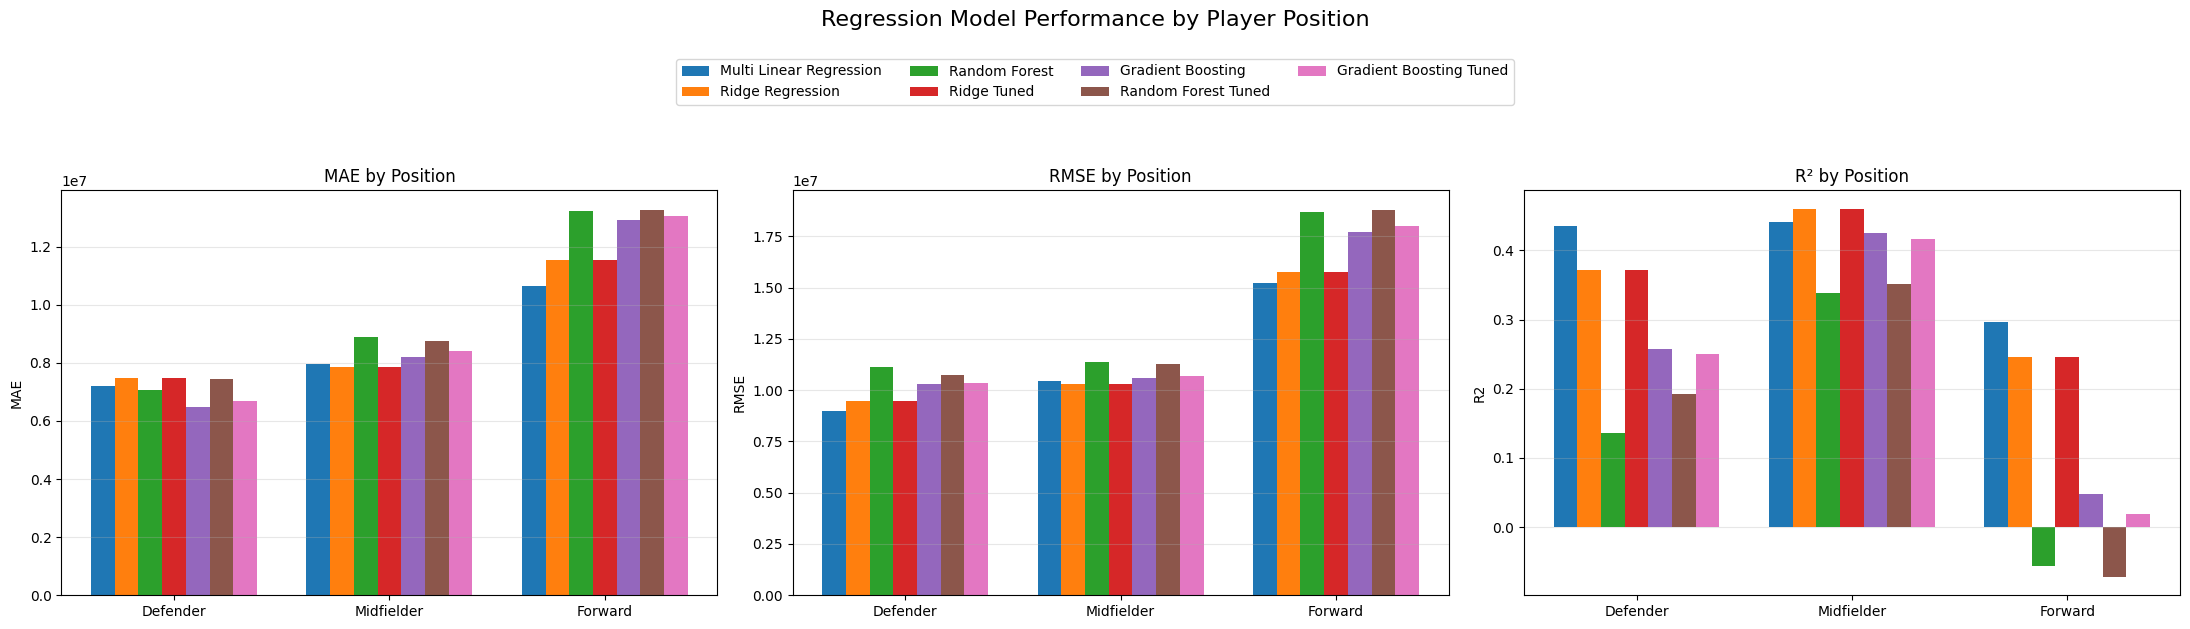

In [82]:
# @title
models = [
    'Multi Linear Regression',
    'Ridge Regression',
    'Random Forest',
    'Ridge Tuned',
    'Gradient Boosting',
    'Random Forest Tuned',
    'Gradient Boosting Tuned'
]

positions = ['Defender', 'Midfielder', 'Forward']

metrics = ['MAE', 'RMSE', 'R2']
titles = [
    'MAE by Position',
    'RMSE by Position',
    'R² by Position'
]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

x = np.arange(len(positions))
width = 0.11

for ax, metric, title in zip(axes, metrics, titles):

    for i, model in enumerate(models):

        values = []

        for position in positions:

            result = model_results[
                (model_results['Model'] == model) &
                (model_results['Position'] == position)
            ]

            if len(result) > 0:
                values.append(result[metric].iloc[0])
            else:
                values.append(np.nan)

        ax.bar(
            x + (i - 3) * width,
            values,
            width,
            label=model
        )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(positions)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)


fig.suptitle(
    'Regression Model Performance by Player Position',
    fontsize=16,
    y=1.04
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.97)
)

plt.tight_layout(rect=[0, 0, 1, 0.86])

plt.show()

### **Choosing the Best Model**

The best model for defenders was Multi Linear Regression. It had a competitive MAE (performance metric) while achieving the highest R2 score by far. Although Gradient Boosting had the lowest MAE, its low R2 score makes it a non-trustworthy model.

The best model for midfielders was Ridge Regression. It achieved the lowest MAE and highest R2 score.

The best model for forwards was Multi Linear Regression. It had the lowest MAE and highest R2 value, making it the best model to choose. Notably, Both Random Forest R2 scores were negative. This shows that the data provided either lacked features for Random Forest to score well on or the dataset was too small.

In [83]:
#picking the best models
defender_best_model = defender_pipe
midfielder_best_model = midfielder_ridge
forward_best_model = forward_pipe


#Predictions
defender_best_pred = defender_best_model.predict(defender_X_test)
midfielder_best_pred = midfielder_best_model.predict(midfielder_X_test)
forward_best_pred = forward_best_model.predict(forward_X_test)

#Results Table
defender_player_results = pd.DataFrame({
    'Player': defenders_df.loc[defender_X_test.index, 'player_name'],
    'Position': 'Defender',
    'Minutes/90s': defenders_df.loc[defender_X_test.index, 'minutes_90s'],
    'Actual Value': defender_y_test,
    'Predicted Value': defender_best_pred
})
midfielder_player_results = pd.DataFrame({
    'Player': midfielders_df.loc[midfielder_X_test.index, 'player_name'],
    'Position': 'Midfielder',
    'Minutes/90s': midfielders_df.loc[midfielder_X_test.index, 'minutes_90s'],
    'Actual Value': midfielder_y_test,
    'Predicted Value': midfielder_best_pred
})
forward_player_results = pd.DataFrame({
    'Player': forwards_df.loc[forward_X_test.index, 'player_name'],
    'Position': 'Forward',
    'Minutes/90s': forwards_df.loc[forward_X_test.index, 'minutes_90s'],
    'Actual Value': forward_y_test,
    'Predicted Value': forward_best_pred
})

#String all the tables together and calculate the valuations gaps
player_results = pd.concat([defender_player_results, midfielder_player_results, forward_player_results])
player_results['Valuation Gap'] = player_results['Predicted Value'] - player_results['Actual Value']

### **Classifying the Players**

In [84]:
#Pull the MAEs for each position
position_mae = {
    'Defender': model_results[(model_results['Model'] == 'Multi Linear Regression') & (model_results['Position'] == 'Defender')]['MAE'].iloc[0],

    'Midfielder': model_results[(model_results['Model'] == 'Ridge Regression') & (model_results['Position'] == 'Midfielder')]['MAE'].iloc[0],

    'Forward': model_results[(model_results['Model'] == 'Multi Linear Regression') & (model_results['Position'] == 'Forward')]['MAE'].iloc[0]
}

#Map each mae to the correct player based on position
player_results['MAE Threshold'] = (
    player_results['Position'].map(position_mae)
)

#Function that returns the type of valuation of a player
def classify_player(row):
    if row['Valuation Gap'] > row['MAE Threshold']:
        return 'Underpriced'
    elif row['Valuation Gap'] < -row['MAE Threshold']:
        return 'Overpriced'
    else:
        return 'Fairly Priced'

player_results['Valuation Status'] = player_results.apply(classify_player, axis=1)

#Returns a confidence level based on the total number of minutes played per 90
def confidence_level(minutes_90):
    if minutes_90 < 1:
        return 'Low'
    elif minutes_90 < 3:
        return 'Moderate'
    else:
        return 'High'

player_results['Confidence'] = player_results['Minutes/90s'].apply(confidence_level)

In [85]:
#Make the Values in Millions to make it more legible
player_results['Actual Value (€M)'] = player_results['Actual Value'] / 1_000_000
player_results['Predicted Value (€M)'] = player_results['Predicted Value'] / 1_000_000
player_results['Valuation Gap (€M)'] = player_results['Valuation Gap'] / 1_000_000

In [86]:
#Find the players who meet the confidence level and are not fairly priced
recommended_players = player_results[
    (player_results['Minutes/90s'] >= 1) &
    (player_results['Valuation Status'] != 'Fairly Priced')
]

#Underpriced Recommended Players
recommended_players[recommended_players['Valuation Status'] == 'Underpriced'].sort_values('Valuation Gap',ascending=False)[['Player', 'Position', 'Minutes/90s','Actual Value (€M)', 'Predicted Value (€M)', 'Valuation Gap (€M)','Confidence']].head(10).round(2)

,Player,Position,Minutes/90s,Actual Value (€M),Predicted Value (€M),Valuation Gap (€M),Confidence
356,Julio Enciso,Forward,4.3,3.14,26.54,23.41,High
921,Jørgen Larsen,Forward,1.2,9.50,24.65,15.15,Moderate
407,Mert Muldur,Defender,1.1,7.00,21.05,14.05,Moderate
317,Auston Trusty,Defender,1.1,6.00,19.96,13.96,Moderate
101,Alexandr Sojka,Midfielder,1.6,2.30,16.16,13.86,Moderate
387,Paul Okon-Engstler,Midfielder,2.2,1.20,13.48,12.28,Moderate
863,Idrissa Gueye,Midfielder,4.0,0.50,12.29,11.79,High
496,Piero Hincapie,Defender,3.8,7.46,17.78,10.32,High
1132,Gustavo Puerta,Defender,5.2,17.77,28.04,10.27,High
126,Niko Sigur,Defender,1.4,4.00,13.70,9.70,Moderate


In [87]:
#Overpriced Unrecommended Players
recommended_players[recommended_players['Valuation Status'] == 'Overpriced'].sort_values('Valuation Gap',ascending=False)[['Player', 'Position', 'Minutes/90s','Actual Value (€M)', 'Predicted Value (€M)', 'Valuation Gap (€M)','Confidence']].head(10).round(2)

,Player,Position,Minutes/90s,Actual Value (€M),Predicted Value (€M),Valuation Gap (€M),Confidence
44,Nkosinathi Sibisi,Defender,1.0,1.60,-6.14,-7.74,Moderate
540,Frenkie Jong,Midfielder,3.6,35.00,26.79,-8.21,High
680,Milad Mohammadi,Defender,2.3,10.54,2.10,-8.43,Moderate
419,Jonathan Tah,Defender,4.1,28.00,19.50,-8.50,High
1186,Martin Baturina,Midfielder,3.6,30.00,20.18,-9.82,High
822,Mathias Olivera,Defender,3.0,21.37,10.27,-11.10,High
315,Tyler Adams,Midfielder,3.8,25.00,13.43,-11.57,High
422,Kai Havertz,Forward,3.9,55.00,43.09,-11.91,High
994,Nicolas Seiwald,Midfielder,3.5,25.00,12.72,-12.28,High
876,Ismaila Sarr,Forward,4.0,40.00,26.45,-13.55,High


### **Applying the Model onto the Original Dataset**

In [88]:
#Training the model on the full dataset by position
X_def_all = defenders_df[defender_X_train.columns]
y_def_all = defenders_df['value']

defender_best_model.fit(X_def_all, y_def_all)
defender_pred_all = defender_best_model.predict(X_def_all)

X_mid_all = midfielders_df[midfielder_X_train.columns]
y_mid_all = midfielders_df['value']

midfielder_best_model.fit(X_mid_all, y_mid_all)
midfielder_pred_all = midfielder_best_model.predict(X_mid_all)

X_for_all = forwards_df[forward_X_train.columns]
y_for_all = forwards_df['value']

forward_best_model.fit(X_for_all, y_for_all)
forward_pred_all = forward_best_model.predict(X_for_all)

In [89]:
#Building all the player tables
defender_all = pd.DataFrame({
    'Player': defenders_df['player_name'],
    'Position': 'Defender',
    'minutes_90s': defenders_df['minutes_90s'],
    'Actual Value': defenders_df['value'],
    'Predicted Value': defender_pred_all
})

midfielder_all = pd.DataFrame({
    'Player': midfielders_df['player_name'],
    'Position': 'Midfielder',
    'minutes_90s': midfielders_df['minutes_90s'],
    'Actual Value': midfielders_df['value'],
    'Predicted Value': midfielder_pred_all
})

forward_all = pd.DataFrame({
    'Player': forwards_df['player_name'],
    'Position': 'Forward',
    'minutes_90s': forwards_df['minutes_90s'],
    'Actual Value': forwards_df['value'],
    'Predicted Value': forward_pred_all
})


In [90]:
#Creating and cleaning the final dataset
all_player_results = pd.concat([defender_all, midfielder_all, forward_all], ignore_index=True)

#Calculated the Valuation Gap for each player
all_player_results['Valuation Gap'] = (all_player_results['Predicted Value'] - all_player_results['Actual Value'])

#Use MAE threshold from test data
all_player_results['MAE Threshold'] = (all_player_results['Position'].map(position_mae))

#Calculate Valuation Status for each player
all_player_results['Valuation Status'] = (all_player_results.apply(classify_player, axis=1))

#Calculate Confidence Level for each player
all_player_results['Confidence'] = (all_player_results['minutes_90s'].apply(confidence_level))

#Convert the values to millions to keep the data set clean
all_player_results['Actual Value (€M)'] = (all_player_results['Actual Value'] / 1_000_000)

all_player_results['Predicted Value (€M)'] = (all_player_results['Predicted Value'] / 1_000_000)

all_player_results['Valuation Gap (€M)'] = (all_player_results['Valuation Gap'] / 1_000_000)


### **Final Findings and Analysis**

In [91]:
pd.crosstab(
    all_player_results['Position'],
    all_player_results['Valuation Status'],
    margins=True
)

Valuation Status,Fairly Priced,Overpriced,Underpriced,All
Position,,,,
Defender,170,28,28,226
Forward,156,20,17,193
Midfielder,158,32,27,217
All,484,80,72,636


The majority of each position has fairly priced players, indicating that the chosen models agreed with the valuations of most of the players. There is also a sufficient amount of overpriced and underpriced players per position, revealing how the model was able to discern meaningful differences between expected and actual market values.

In [92]:
#Top Underpriced Players
top_underpriced = all_player_results[(all_player_results['Valuation Status'] == 'Underpriced') &(all_player_results['Confidence'].isin(['Moderate', 'High']))].sort_values('Valuation Gap', ascending=False)
top_underpriced[['Player', 'Position', 'minutes_90s', 'Actual Value (€M)', 'Predicted Value (€M)', 'Valuation Gap (€M)', 'Confidence']].head(10).round(2)



,Player,Position,minutes_90s,Actual Value (€M),Predicted Value (€M),Valuation Gap (€M),Confidence
584,Sadio Mane,Forward,4.0,6.00,28.04,22.04,High
574,Mikel Oyarzabal,Forward,6.7,35.00,56.50,21.50,High
524,Deniz Undav,Forward,1.7,22.00,41.33,19.33,Moderate
534,Elye Wahi,Forward,1.2,5.94,22.66,16.72,Moderate
351,Hans Vanaken,Midfielder,3.5,5.00,21.44,16.44,High
375,Habib Diarra,Midfielder,1.6,7.40,23.40,15.99,Moderate
206,John Stones,Defender,3.7,12.00,27.42,15.42,High
604,Joao Felix,Forward,2.2,17.43,32.30,14.87,Moderate
100,Emmanuel Agbadou,Defender,3.0,3.64,18.15,14.51,High
171,Gonzalo Montiel,Defender,2.1,4.50,18.62,14.12,Moderate


In [93]:
#Top Overpriced Players
top_overpriced = all_player_results[(all_player_results['Valuation Status'] == 'Overpriced') &(all_player_results['Confidence'].isin(['Moderate', 'High']))].sort_values('Valuation Gap', ascending=False)
top_overpriced[['Player', 'Position', 'minutes_90s', 'Actual Value (€M)', 'Predicted Value (€M)', 'Valuation Gap (€M)', 'Confidence']].head(10).round(2)


,Player,Position,minutes_90s,Actual Value (€M),Predicted Value (€M),Valuation Gap (€M),Confidence
152,Mathias Olivera,Defender,3.0,21.37,13.67,-7.69,High
146,Michael Boxall,Defender,2.3,0.15,-7.60,-7.75,Moderate
260,Denis Zakaria,Midfielder,4.0,16.55,8.64,-7.91,High
398,Nicolas Seiwald,Midfielder,3.5,25.00,17.00,-8.00,High
123,Gabriel Gudmundsson,Defender,3.7,20.00,11.88,-8.12,High
296,Hakan Calhanoglu,Midfielder,2.0,16.00,7.81,-8.19,Moderate
324,Frenkie Jong,Midfielder,3.6,35.00,26.57,-8.43,High
203,Deiver Machado,Defender,1.0,25.91,17.36,-8.54,Moderate
366,Federico Valverde,Midfielder,2.6,15.93,7.27,-8.66,Moderate
424,Jefferson Lerma,Midfielder,4.6,27.02,18.19,-8.83,High


Note that the predicted value for some players are negative. This was left in intentionally to show their overvaluation. In a perfect world, these values should be zero, but in order to maintain data integrity, they were left as is.

In [94]:
pio.renderers.default = "notebook_connected"
positions = ['Defender', 'Midfielder', 'Forward']

for position in positions:

    position_data = all_player_results[
        all_player_results['Position'] == position
    ]

    fig = px.scatter(
        position_data,
        x='Actual Value (€M)',
        y='Predicted Value (€M)',
        color='Valuation Status',

        # Information shown when hovering
        hover_name='Player',

        hover_data={
            'Position': True,
            'minutes_90s': ':.2f',
            'Actual Value (€M)': ':.2f',
            'Predicted Value (€M)': ':.2f',
            'Valuation Gap (€M)': ':.2f',
            'Confidence': True
        },

        title=f'Actual vs Predicted Market Value - {position}s'
    )

    # Perfect prediction line
    min_value = min(
        position_data['Actual Value (€M)'].min(),
        position_data['Predicted Value (€M)'].min()
    )

    max_value = max(
        position_data['Actual Value (€M)'].max(),
        position_data['Predicted Value (€M)'].max()
    )

    fig.add_shape(
        type='line',
        x0=min_value,
        y0=min_value,
        x1=max_value,
        y1=max_value,
        line=dict(dash='dash')
    )

    fig.update_layout(
        width=950,
        height=650
    )

    fig.show()

Highlight over the point that you want to study and a box with player information will pop up!